1️⃣ Load the dataset

In [2]:
import pandas as pd

# Load raw CSV (adjust path if needed)
df = pd.read_csv('../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv')

# Quick peek
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


2️⃣ Basic sanity checks
###### Missing values
###### Duplicates
###### Data types

In [3]:
# Missing values
missing = df.isnull().sum()
print(missing[missing > 0])

# Duplicate URLs
dupes = df['URL'].duplicated().sum()
print(f'Duplicates: {dupes}')

# Check data types
print(df.dtypes)

Series([], dtype: int64)
Duplicates: 425
FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS  

3️⃣ Target distribution
Visualize phishing vs legitimate

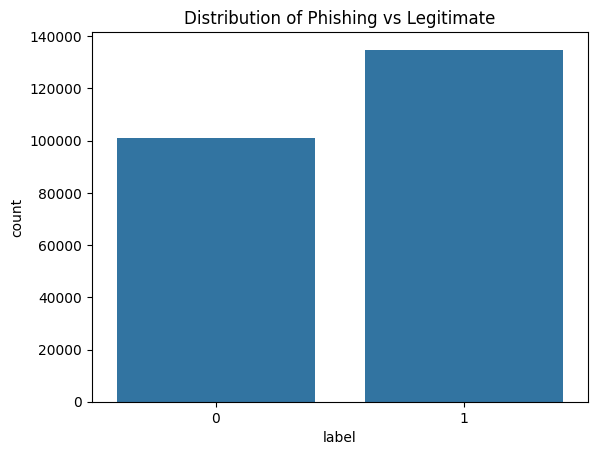

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=df)
plt.title('Distribution of Phishing vs Legitimate')
plt.show()

4️⃣ Feature exploration

Continuous vs categorical
Examples:

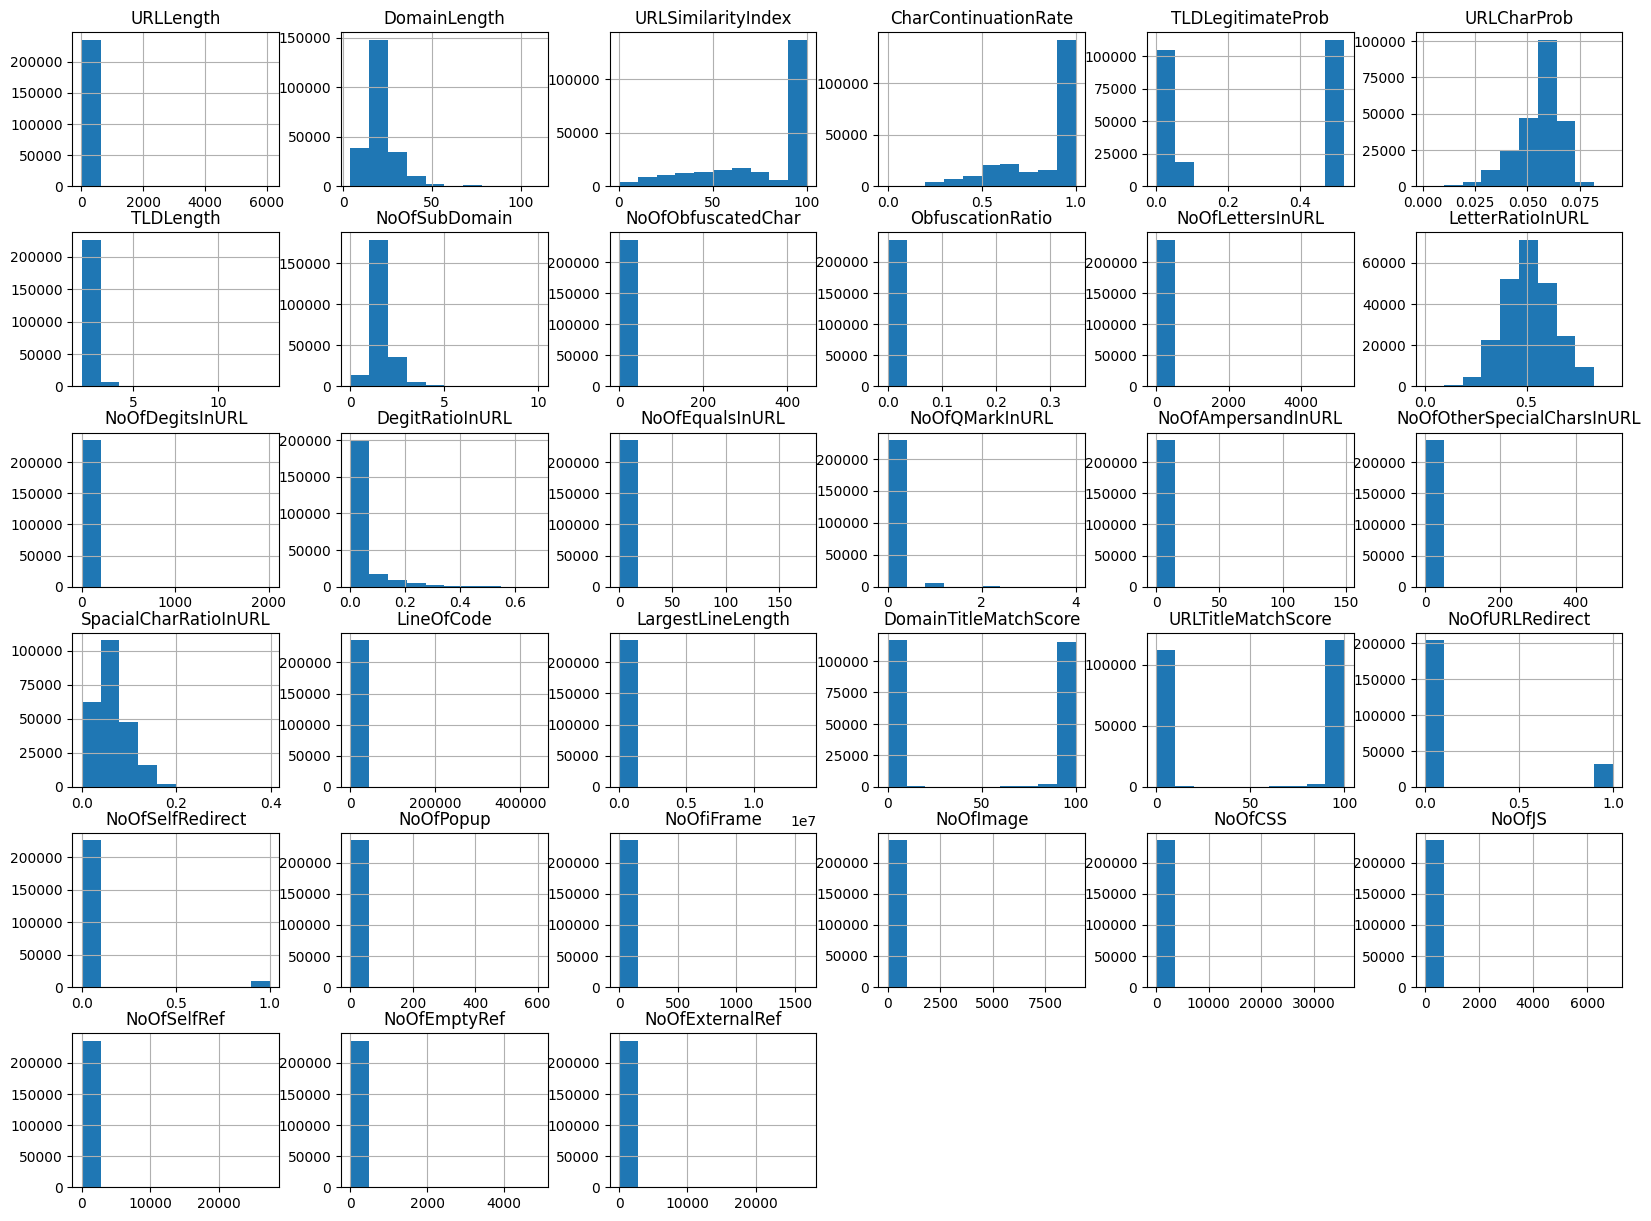

In [5]:
# Numeric features summary
numeric_features = ['URLLength', 'DomainLength', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
                    'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'NoOfObfuscatedChar', 'ObfuscationRatio',
                    'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
                    'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL',
                    'LineOfCode', 'LargestLineLength', 'DomainTitleMatchScore', 'URLTitleMatchScore', 
                    'NoOfURLRedirect', 'NoOfSelfRedirect', 'NoOfPopup', 'NoOfiFrame', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
                    'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']

df[numeric_features].hist(figsize=(20,15))
plt.show()

Categorical/binary features:

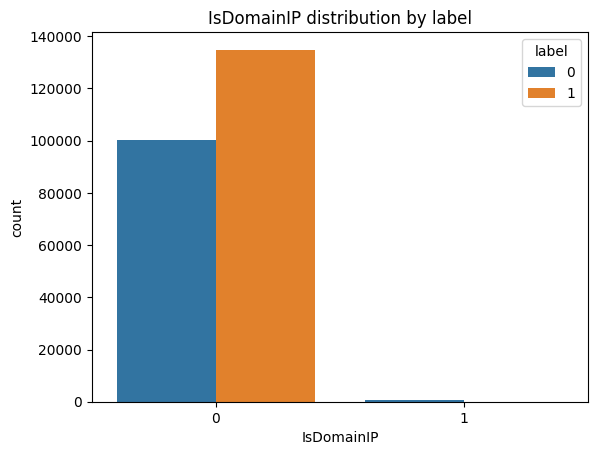

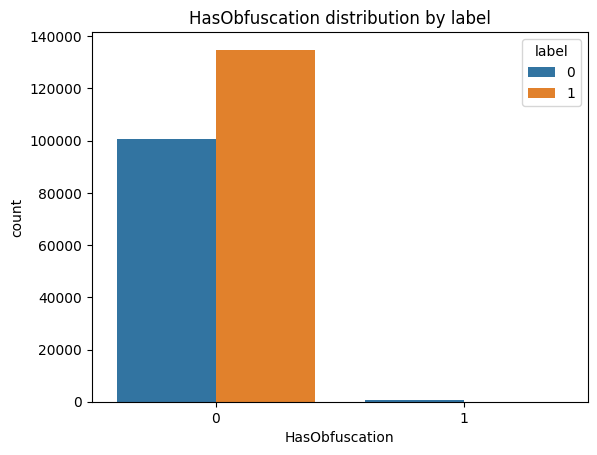

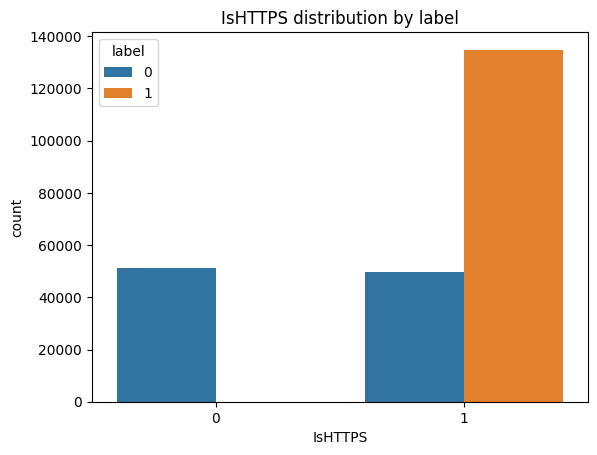

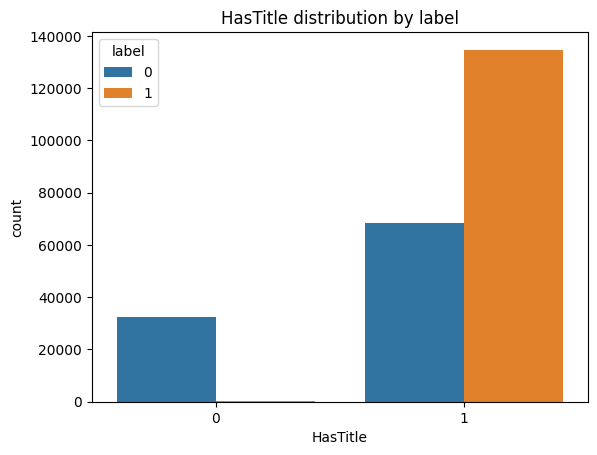

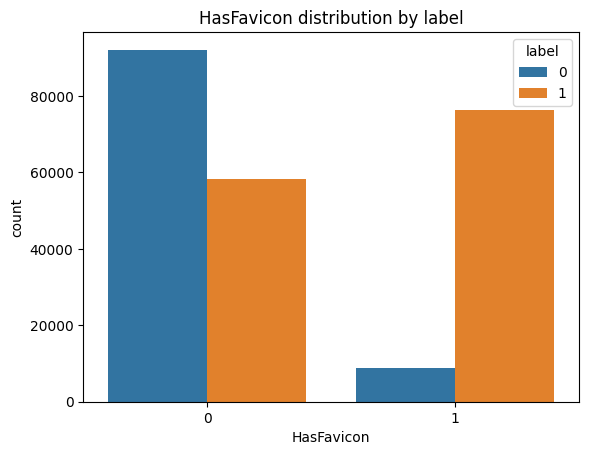

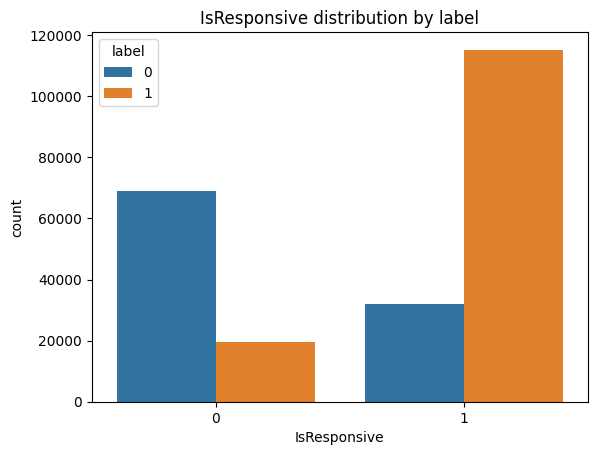

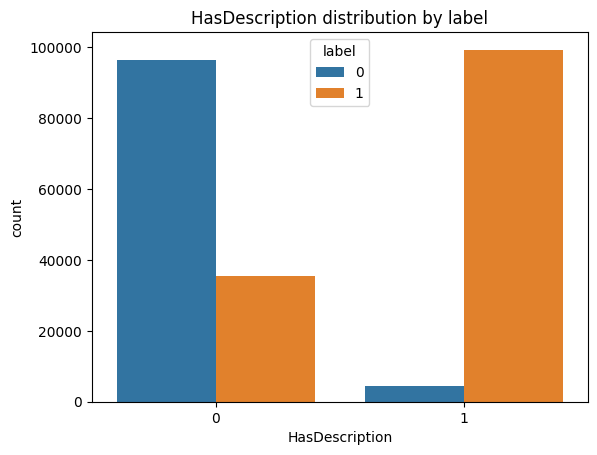

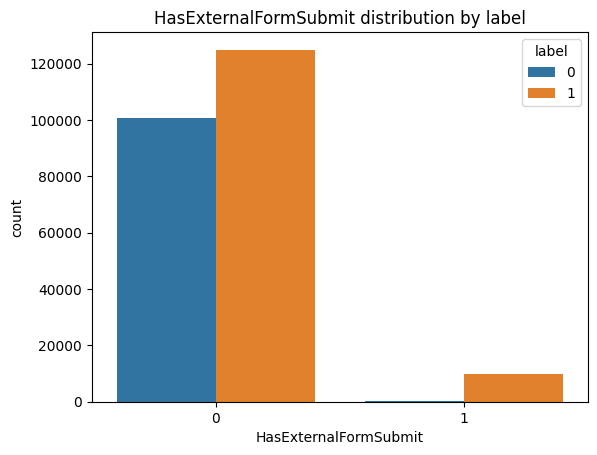

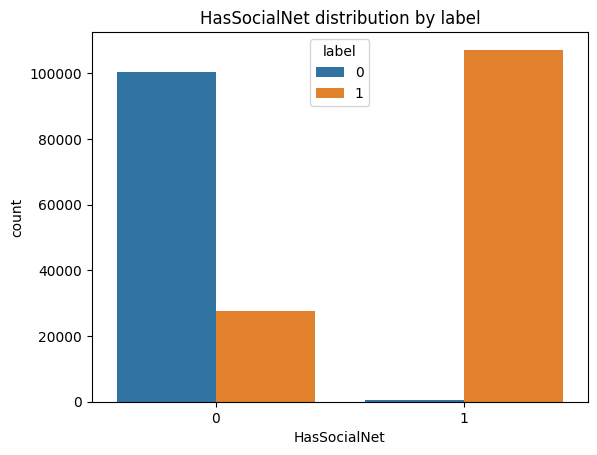

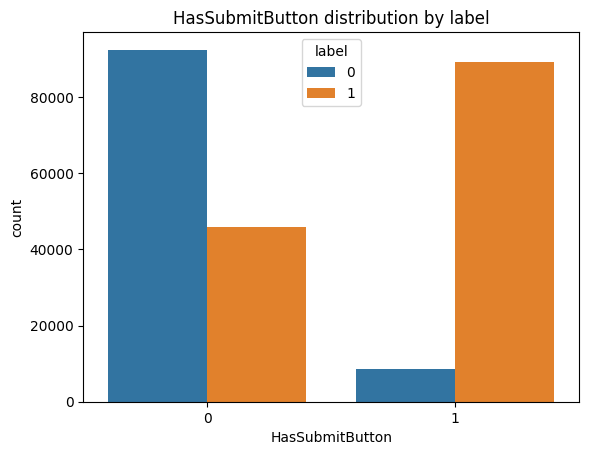

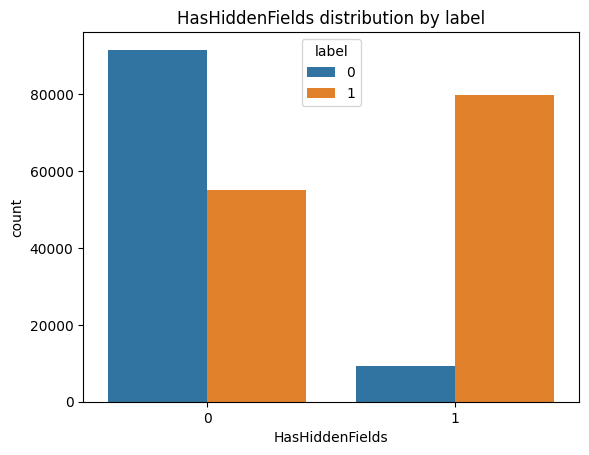

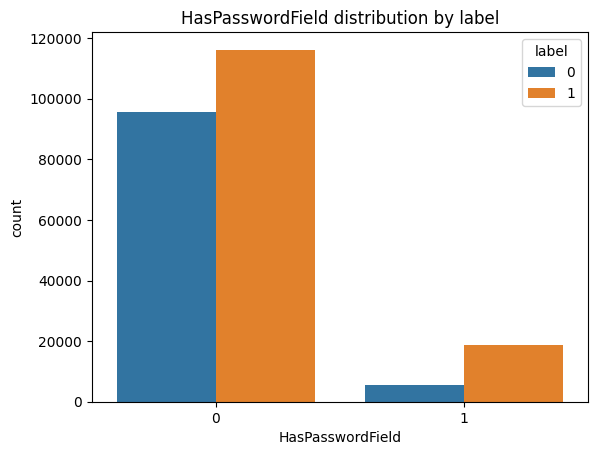

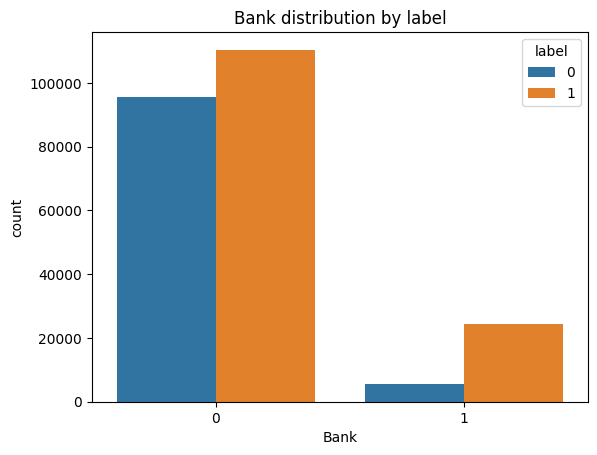

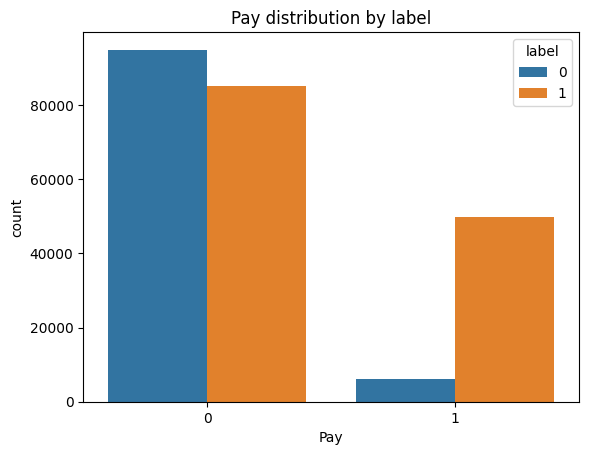

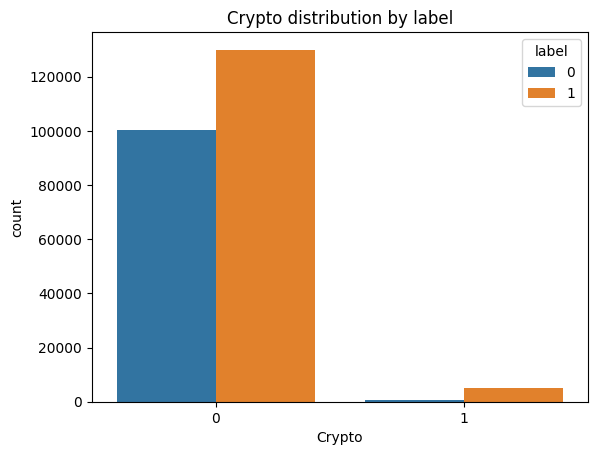

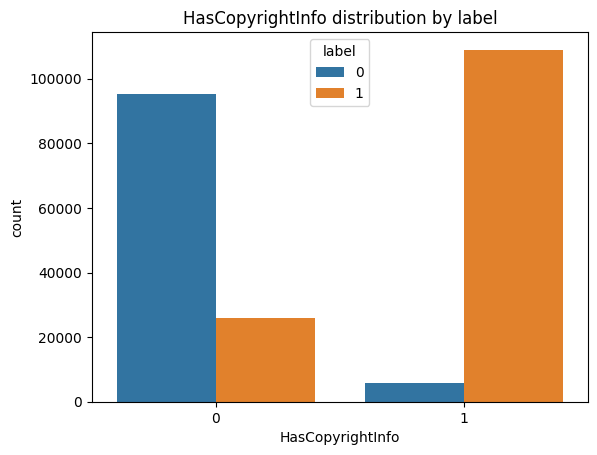

In [6]:
binary_features = ['IsDomainIP','HasObfuscation','IsHTTPS','HasTitle','HasFavicon','IsResponsive',
                   'HasDescription','HasExternalFormSubmit','HasSocialNet','HasSubmitButton','HasHiddenFields',
                   'HasPasswordField','Bank','Pay','Crypto','HasCopyrightInfo']

for col in binary_features:
    sns.countplot(x=col, hue='label', data=df)
    plt.title(f'{col} distribution by label')
    plt.show()

1️⃣ Check Feature Importance (Early Signal Peek)

This gives you a preview of what actually matters before full modeling.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Drop non-usable columns
drop_cols = ["FILENAME", "URL", "Domain", "Title"]
df_model = df.drop(columns=drop_cols)

X = df_model.drop("label", axis=1)
y = df_model["label"]

X.dtypes[X.dtypes == "object"]



TLD    object
dtype: object

In [10]:
X = pd.get_dummies(X, drop_first=True)


model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15)

URLSimilarityIndex            0.094116
NoOfImage                     0.093139
NoOfExternalRef               0.081614
NoOfSelfRef                   0.075190
LineOfCode                    0.074773
NoOfJS                        0.060695
HasSocialNet                  0.044582
IsHTTPS                       0.044344
NoOfCSS                       0.043752
NoOfOtherSpecialCharsInURL    0.034702
HasSubmitButton               0.032832
HasDescription                0.032152
LargestLineLength             0.026364
IsResponsive                  0.024512
HasCopyrightInfo              0.024012
dtype: float64

2️⃣ Check Class Imbalance (VERY IMPORTANT)

In [11]:
df['label'].value_counts(normalize=True)

label
1    0.571895
0    0.428105
Name: proportion, dtype: float64

3️⃣ Outlier Detection (Silent Model Killer)

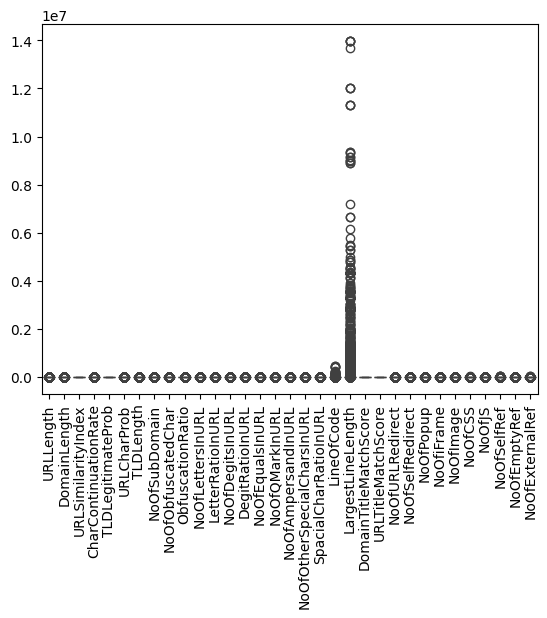

In [12]:
import seaborn as sns

sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=90)
plt.show()